Learned weights: [2. 3.]
Learned bias:    -4
Decision boundary: 2.0·x1 + 3.0·x2 + -4.0 = 0


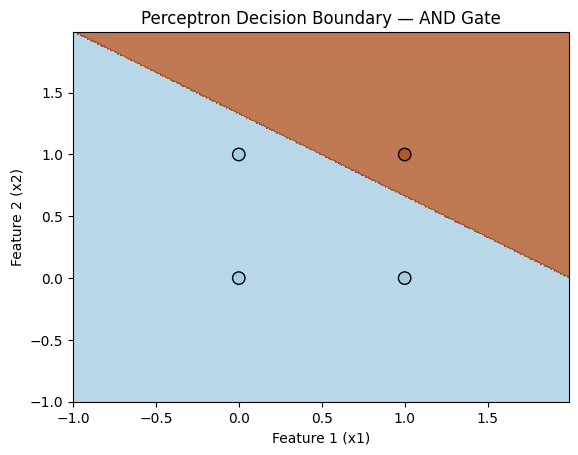

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── What this does ───────────────────────────────────────────────────────
# Trains a Perceptron on AND gate data and draws the decision boundary.
# Labels: +1 = AND is TRUE, -1 = AND is FALSE
# ────────────────────────────────────────────────────────────────────────

# ── Step 1: The Perceptron neuron ────────────────────────────────────────
# np.sign() gives: +1 if positive, -1 if negative, 0 if zero
# This replaces the step function from the previous practical.
# Formula:  output = sign( x·w + b )
#   x = input point  (e.g. [1, 0])
#   w = weights      (learned during training)
#   b = bias         (shifts the line away from the origin)
def perceptron(x, w, b):
    return np.sign(np.dot(x, w) + b)

# ── Step 2: The learning algorithm ──────────────────────────────────────
# eta   = learning rate (how big each weight update step is)
# epochs = how many full passes through the training data
def perceptron_learning(X, Y, eta, epochs):
    w = np.zeros(2)   # start with weights [0, 0]
    b = 0             # start with bias 0

    for epoch in range(epochs):           # repeat multiple times
        for i in range(len(X)):           # look at each training point
            prediction = perceptron(X[i], w, b)

            if prediction != Y[i]:        # only update on mistakes
                # Perceptron Learning Rule:
                #   if wrong, nudge w and b toward the correct answer
                w = w + eta * Y[i] * X[i]
                b = b + eta * Y[i]
                # Y[i] is +1 or -1, so this either adds or subtracts

    return w, b   # return the learned weights and bias

# ── Step 3: Training data (AND gate) ────────────────────────────────────
#   Input       AND output
#   [0, 0]  →     -1  (False AND False = False)
#   [1, 0]  →     -1  (True  AND False = False)
#   [0, 1]  →     -1  (False AND True  = False)
#   [1, 1]  →     +1  (True  AND True  = True)
X = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
Y = np.array([-1, -1, -1, 1])

# ── Step 4: Train the perceptron ─────────────────────────────────────────
w, b = perceptron_learning(X, Y, eta=1, epochs=10)
print(f"Learned weights: {w}")
print(f"Learned bias:    {b}")
print(f"Decision boundary: {w[0]:.1f}·x1 + {w[1]:.1f}·x2 + {b:.1f} = 0")

# ── Step 5: Draw the decision regions ───────────────────────────────────
# Create a dense grid of points covering the plot area
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1   # x-axis range: -1 to 2
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1   # y-axis range: -1 to 2

# meshgrid creates a grid of (x, y) coordinate pairs, 0.01 apart
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Ask the trained perceptron to classify every point on the grid
Z = np.array([perceptron(np.array([x, y]), w, b)
              for x, y in np.c_[xx.ravel(), yy.ravel()]])
Z = Z.reshape(xx.shape)   # reshape back to grid shape for plotting

# contourf fills regions with colour based on perceptron's output
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

# scatter plots the 4 actual training points on top
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired, edgecolors='black', s=80)

plt.xlabel('Feature 1 (x1)')
plt.ylabel('Feature 2 (x2)')
plt.title('Perceptron Decision Boundary — AND Gate')
plt.show()

Key Concepts to Lock In for Your Exam
What is np.sign()?
It returns +1 for positive numbers, −1 for negative numbers, and 0 for exactly zero. It replaces the 0/1 step function — using ±1 labels makes the math cleaner because the error is symmetric.

What is the bias b?
A learnable constant added to the weighted sum. Without it, the decision boundary is forced to pass through the origin. With it, the boundary can shift anywhere in space. The bias update rule b += eta * Y[i] is the same as a weight connected to an input that is permanently 1.

Why np.meshgrid?
To draw the colored background regions, you need to classify thousands of points covering the entire plot area. meshgrid creates a grid of coordinate pairs, the Perceptron classifies each one, and contourf (or manual canvas drawing here) colors the regions accordingly.

What is np.c_[xx.ravel(), yy.ravel()]?
ravel() flattens the 2D grid into a 1D list. np.c_ zips two arrays column-wise, creating pairs [x, y]. It's just a compact way to make a list of every grid coordinate.

Exam Questions
Q1. What is the difference between np.sign() and the step function?
Step function outputs 0 or 1 — used with 0/1 labels. np.sign() outputs −1 or +1 — used with ±1 labels. Both implement a threshold decision, just with different scales.

Q2. What does the bias term do geometrically?
It translates (shifts) the decision boundary. Without bias, the line must pass through the origin. With bias, it can be anywhere — which is necessary for AND, since the separating line doesn't pass through (0,0).

Q3. Why does the update only happen when prediction != Y[i]?
When the prediction is correct, error = 0, so the weight update w += eta * Y[i] * X[i] would be fine mathematically, but here we check explicitly — it's the same logic, just written as a conditional for clarity.

Q4. What does epochs=10 mean?
The algorithm passes through all 4 training examples 10 times — 40 total update opportunities. More epochs give the Perceptron more chances to correct its mistakes and converge.

Q5. Is AND gate linearly separable?
Yes — you can draw a single straight line to separate the one +1 point [1,1] from the three −1 points. That's exactly what the decision boundary in the plot shows.